In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
heart = pd.read_csv('heart.csv')

In [5]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
heart = heart.astype({
    'Sex': 'category',
    'ChestPainType': 'category',
    'RestingECG': 'category',
    'ExerciseAngina': 'category',
    'ST_Slope': 'category',

})

In [9]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Age             918 non-null    int64   
 1   Sex             918 non-null    category
 2   ChestPainType   918 non-null    category
 3   RestingBP       918 non-null    int64   
 4   Cholesterol     918 non-null    int64   
 5   FastingBS       918 non-null    int64   
 6   RestingECG      918 non-null    category
 7   MaxHR           918 non-null    int64   
 8   ExerciseAngina  918 non-null    category
 9   Oldpeak         918 non-null    float64 
 10  ST_Slope        918 non-null    category
 11  HeartDisease    918 non-null    int64   
dtypes: category(5), float64(1), int64(6)
memory usage: 55.5 KB


In [13]:
heart.describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


In [15]:
heart.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [17]:
heart[heart.duplicated()]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [219]:
heart.groupby(["HeartDisease","Sex"])["Cholesterol"].agg(["mean","max","min"])

mean  max  min
HeartDisease Sex                      
0            F    249.183099  564  141
             M    232.806452  458   85
1            F    279.175000  409  164
             M    247.503165  603  100

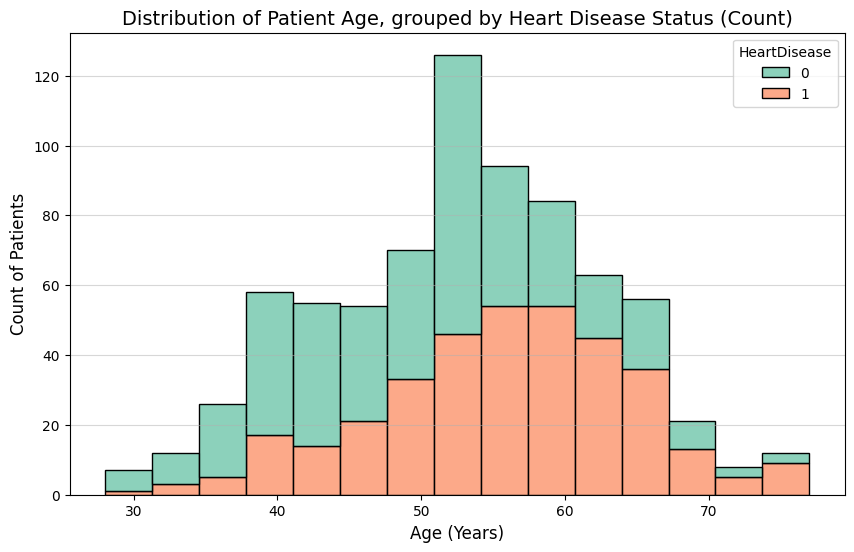

In [571]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=heart,
    x='Age',
    hue='HeartDisease',  
    multiple='stack',    # Stacks the bars for count comparison
    bins=15,
    palette = 'Set2'
)

plt.title('Distribution of Patient Age, grouped by Heart Disease Status (Count)', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Count of Patients', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

In [361]:
heart.groupby('Sex')['Sex'].size()

Sex
F    182
M    564
Name: Sex, dtype: int64

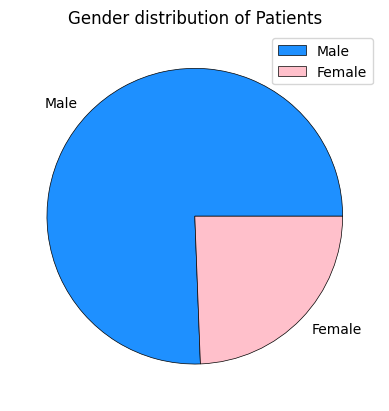

In [511]:
plt.pie([564,182], labels = ["Male","Female"],
        colors = ['dodgerblue', 'pink'],
        wedgeprops={'edgecolor': 'black',
                    'linewidth': 0.5})
plt.legend()
plt.title('Gender distribution of Patients')
plt.show()

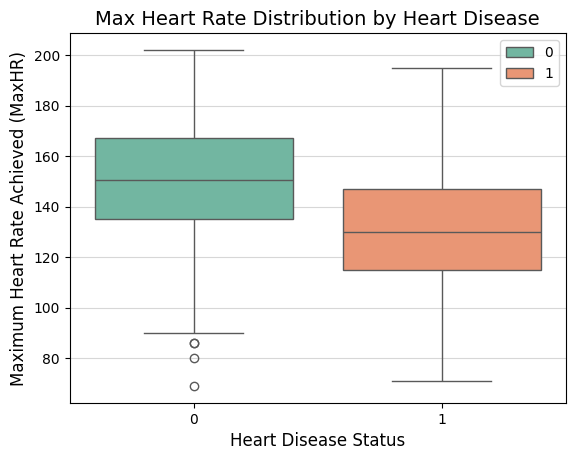

In [507]:
sns.boxplot(
    x='HeartDisease', 
    y='MaxHR',         
    data=heart,
    hue = 'HeartDisease',
    palette='Set2'     
)

plt.title('Max Heart Rate Distribution by Heart Disease', fontsize=14)
plt.xlabel('Heart Disease Status', fontsize=12)
plt.ylabel('Maximum Heart Rate Achieved (MaxHR)', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

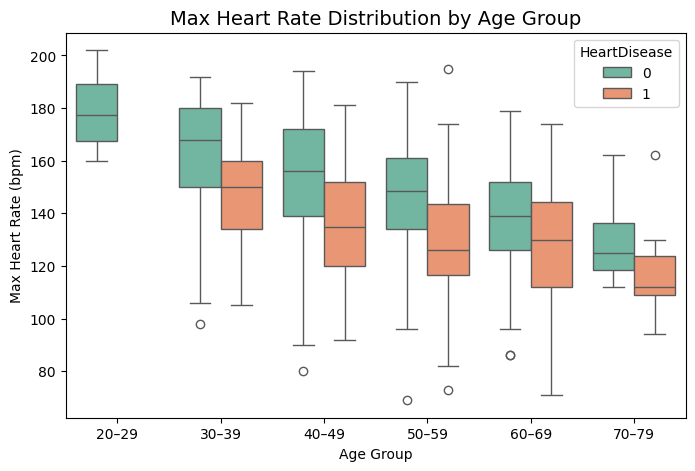

In [49]:
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['20–29', '30–39', '40–49', '50–59', '60–69', '70–79']

heart['AgeGroup'] = pd.cut(heart['Age'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(8,5))
sns.boxplot(x='AgeGroup', y='MaxHR', data=heart,hue = 'HeartDisease' ,palette='Set2')

plt.title('Max Heart Rate Distribution by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Max Heart Rate (bpm)')
plt.show()

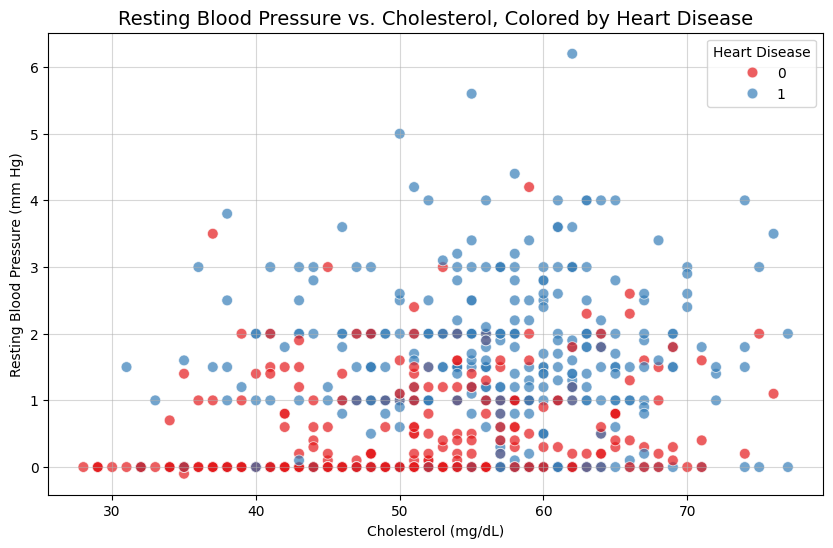

In [521]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=heart,
    x='Age',
    y='Oldpeak',
    hue='HeartDisease',  
    palette='Set1',      
    s=60,                
    alpha=0.7           
)

plt.title('Resting Blood Pressure vs. Cholesterol, Colored by Heart Disease', fontsize=14)
plt.xlabel('Cholesterol (mg/dL)')
plt.ylabel('Resting Blood Pressure (mm Hg)')
plt.legend(title='Heart Disease')
plt.grid(True, alpha=0.5)
plt.show()

In [101]:
heart_corr = heart.corr(numeric_only=True)
heart_corr

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.259865,0.058758,0.241338,-0.382112,0.286006,0.298617
RestingBP,0.259865,1.000000,0.095939,0.173765,-0.125774,0.198575,0.173242
Cholesterol,0.058758,0.095939,1.000000,0.054012,-0.019856,0.058488,0.103866
FastingBS,0.241338,0.173765,0.054012,1.000000,-0.102710,0.055568,0.160594
MaxHR,-0.382112,-0.125774,-0.019856,-0.102710,1.000000,-0.259533,-0.377212
Oldpeak,0.286006,0.198575,0.058488,0.055568,-0.259533,1.000000,0.495696
HeartDisease,0.298617,0.173242,0.103866,0.160594,-0.377212,0.495696,1.000000


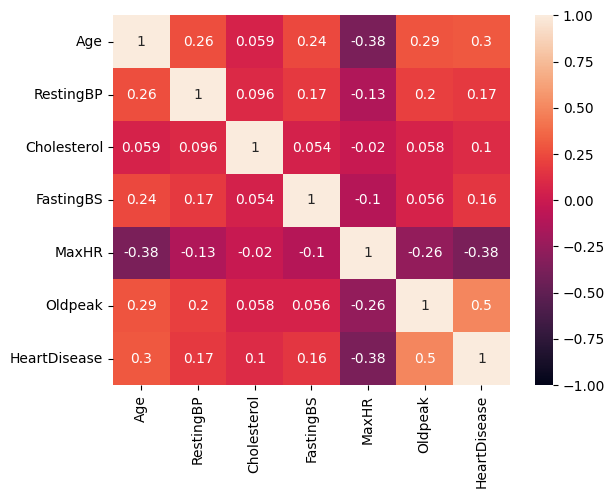

In [103]:
sns.heatmap(heart_corr, vmin = -1, vmax = 1, annot = True)
plt.show()

In [21]:
heart_corr = heart.corr(numeric_only=True)
heart_corr

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
Age,1.000000,0.259865,0.058758,-0.382112,0.286006
RestingBP,0.259865,1.000000,0.095939,-0.125774,0.198575
Cholesterol,0.058758,0.095939,1.000000,-0.019856,0.058488
MaxHR,-0.382112,-0.125774,-0.019856,1.000000,-0.259533
Oldpeak,0.286006,0.198575,0.058488,-0.259533,1.000000
